# <font color="brown">Support Vector Machine (SVM) Case Study </font>

## <font color = "brown">Problem Statement </font>
Build a model to predict whether a customer will default on a loan based on the data shared, and compare how different SVM kernels perform on this problem.

## <font color = "brown">Data Dictionary </font>
| Column Name | Meaning / Description | Data Type | Example Values |
| --- | --- | --- | --- |
| **Customer_ID** | Unique customer identifier | Integer | `100001`, `100245` |
| **Status_Checking_Acc** | Status of checking (current) account | Categorical | `A11`, `A12`, `A13`, `A14` |
| **Duration_in_Months** | Loan duration in months | Numeric | `6`, `24`, `48` |
| **Credit_History** | Customer credit repayment history | Categorical | `A30`, `A31`, `A32`, `A33`, `A34` |
| **Purposre_Credit_Taken** *(Purpose)* | Purpose of loan | Categorical | `A40`, `A41`, `A42`, `A43`, `A46` |
| **Credit_Amount** | Loan amount requested/approved | Numeric | `1169`, `5000`, `7882` |
| **Savings_Acc** | Savings account/bond holdings | Categorical | `A61`, `A62`, `A63`, `A64`, `A65` |
| **Years_At_Present_Employment** | Employment tenure at current job | Categorical | `A71`, `A72`, `A73`, `A74`, `A75` |
| **Inst_Rt_Income** | Installment rate as % of disposable income | Numeric | `1`, `2`, `3`, `4` |
| **Marital_Status_Gender** | Marital status & gender combined | Categorical | `A91`, `A92`, `A93`, `A94` |
| **Other_Debtors_Guarantors** | Guarantor / co-applicant | Categorical | `A101`, `A102`, `A103` |
| **Current_Address_Yrs** | Years living at current residence | Numeric | `1`, `2`, `3`, `4` |
| **Property** | Major assets held | Categorical | `A121`, `A122`, `A123`, `A124` |
| **Age** | Customer age in years | Numeric | `22`, `35`, `49`, `67` |
| **Other_Inst_Plans** | Other installment plans | Categorical | `A141`, `A142`, `A143` |
| **Housing** | Housing status | Categorical | `A151`, `A152`, `A153` |
| **Num_CC** | # of existing credit accounts | Numeric | `1`, `2`, `3` |
| **Job** | Customer job skill level | Categorical | `A171`, `A172`, `A173`, `A174` |
| **Dependents** | Number of financial dependents | Numeric | `1`, `2` |
| **Telephone** | Telephone availability | Categorical | `A191`, `A192` |
| **Foreign_Worker** | Whether a foreign worker | Categorical | `A201`, `A202` |
| **Default_On_Payment** | **Target variable**: 1 = default, 0 = no default | Binary | `0`, `1` |

### <font color="blue"> Importing the libraries required

In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.datasets import make_blobs, make_circles
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)

%matplotlib inline

### <font color="blue"> Reading file and understanding the data

In [5]:
data = pd.read_csv("default_on_payment.csv")

In [6]:
#Creating a copy of the data
df = data.copy()

**Let us check the shape of the data**

In [8]:
df.shape

(34783, 22)

The data has 34,783 observations and 22 features.

**Checking the data types**

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34783 entries, 0 to 34782
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Customer_ID                  34783 non-null  int64 
 1   Status_Checking_Acc          34783 non-null  object
 2   Duration_in_Months           34783 non-null  int64 
 3   Credit_History               34783 non-null  object
 4   Purposre_Credit_Taken        34783 non-null  object
 5   Credit_Amount                34783 non-null  int64 
 6   Savings_Acc                  34783 non-null  object
 7   Years_At_Present_Employment  34783 non-null  object
 8   Inst_Rt_Income               34783 non-null  int64 
 9   Marital_Status_Gender        34783 non-null  object
 10  Other_Debtors_Guarantors     34783 non-null  object
 11  Current_Address_Yrs          34783 non-null  int64 
 12  Property                     34783 non-null  object
 13  Age                          34

### <font color="blue"> Missing Value Check

In [13]:
df.isna().sum()

Customer_ID                    0
Status_Checking_Acc            0
Duration_in_Months             0
Credit_History                 0
Purposre_Credit_Taken          0
Credit_Amount                  0
Savings_Acc                    0
Years_At_Present_Employment    0
Inst_Rt_Income                 0
Marital_Status_Gender          0
Other_Debtors_Guarantors       0
Current_Address_Yrs            0
Property                       0
Age                            0
Other_Inst_Plans               0
Housing                        0
Num_CC                         0
Job                            0
Dependents                     0
Telephone                      0
Foreign_Worker                 0
Default_On_Payment             0
dtype: int64

There are no missing values in the data.

### <font color="blue"> Checking Duplicates

In [16]:
df.duplicated().sum()

0

There are no duplicate rows in the data.

**Checking the target class balance**

In [19]:
df['Default_On_Payment'].value_counts(normalize=True)

Default_On_Payment
0    0.600638
1    0.399362
Name: proportion, dtype: float64

## <font color="brown"> Understanding Support Vector Machines

A **Support Vector Machine** tries to find the boundary (a line in 2D, a plane or hyperplane in higher dimensions) that separates the two classes with the **widest possible margin**, the widest gap between the boundary and the nearest points of each class. Those nearest points are called **support vectors**, they are the only points that actually decide where the boundary goes, everything further away doesn't matter.

Not every dataset can be separated well with a straight line, though. That's where **kernels** come in: a kernel is simply a different way of measuring how "similar" two points are, which changes the *shape* of the boundary SVM is able to draw. (For the full mathematical explanation of margins and kernels in simple terms, see the companion `SVM Teaching Note.ipynb`.)

## <font color="brown"> Kernel Types in SVM

Before applying these to our credit data, let's build each kernel on small, easy-to-visualise toy datasets, so we can actually *see* what shape of boundary each one draws.

### <font color="blue"> 1. Linear Kernel

$$K(x, y) = x \cdot y$$

The simplest kernel, no transformation at all, just a straight line/plane in the original feature space. Fast, easy to interpret (the coefficients tell you directly how much each feature matters), and works well when the classes are already close to linearly separable.

### <font color="blue"> 2. Polynomial Kernel

$$K(x, y) = (\gamma \cdot x \cdot y + r)^d$$

Effectively creates new features by combining the originals up to degree $d$ (e.g. squares, products of pairs of features), letting the boundary curve. More flexible than linear, but higher degrees get slow and can overfit easily.

### <font color="blue"> 3. RBF (Radial Basis Function / Gaussian) Kernel

$$K(x, y) = \exp(-\gamma \cdot \lVert x - y \rVert^2)$$

Measures similarity based on *distance* between points, points close together are "similar", points far apart are not. This lets SVM draw smooth, closed, curved boundaries (like circles/blobs around clusters), and is the default kernel in scikit-learn because it handles non-linear data well in most cases. Its main hyperparameter, `gamma`, controls how far the influence of a single point reaches, high gamma means each point only affects its immediate neighbourhood (a tighter, wigglier boundary, more prone to overfitting), low gamma means a smoother, more global boundary.

### <font color="blue"> 4. Sigmoid Kernel

$$K(x, y) = \tanh(\gamma \cdot x \cdot y + r)$$

Behaves similarly to a single-layer neural network. It's used far less often in practice, it isn't always a mathematically well-behaved ("valid") kernel for every choice of parameters, and it tends to produce messier, less reliable boundaries than RBF, but it's worth seeing what it actually does.

**Let's visualise all four.** We'll fit the linear kernel on a simple dataset with two well-separated blobs, and the other three on a trickier dataset, two concentric circles, which is impossible to separate with a straight line, to see how each kernel copes.

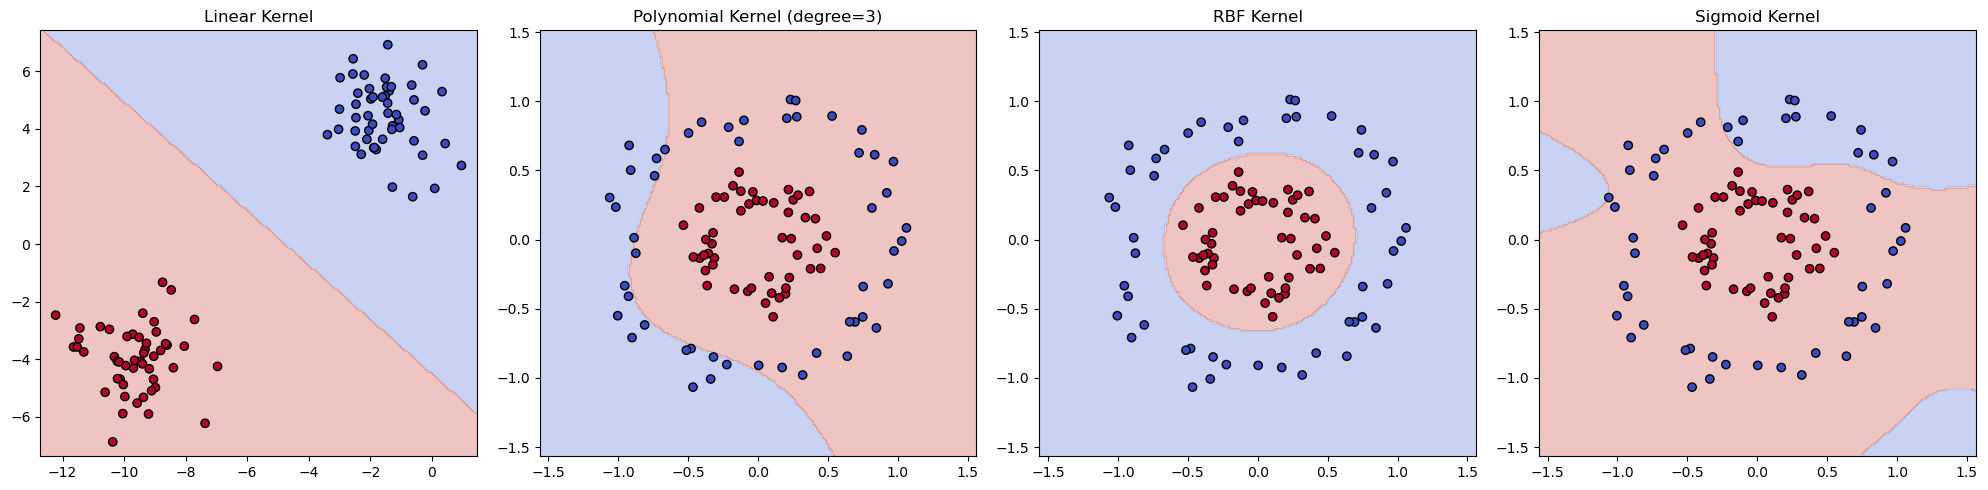

In [27]:
def plot_kernel_boundary(ax, X, y, kernel, title, **kwargs):
    model = SVC(kernel=kernel, random_state=1, **kwargs).fit(X, y)
    xx, yy = np.meshgrid(
        np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 200),
        np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 200),
    )
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k')
    ax.set_title(title)


X_linear_demo, y_linear_demo = make_blobs(n_samples=100, centers=2, cluster_std=1.2, random_state=1)
X_circle_demo, y_circle_demo = make_circles(n_samples=100, noise=0.1, factor=0.4, random_state=1)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
plot_kernel_boundary(axes[0], X_linear_demo, y_linear_demo, 'linear', 'Linear Kernel')
plot_kernel_boundary(axes[1], X_circle_demo, y_circle_demo, 'poly', 'Polynomial Kernel (degree=3)', degree=3)
plot_kernel_boundary(axes[2], X_circle_demo, y_circle_demo, 'rbf', 'RBF Kernel')
plot_kernel_boundary(axes[3], X_circle_demo, y_circle_demo, 'sigmoid', 'Sigmoid Kernel')
plt.tight_layout()
plt.show()

* The **linear** kernel draws exactly what we'd expect, a straight line between the two blobs.
* On the two concentric circles (which no straight line can separate), the **polynomial** kernel manages a rough, somewhat blocky curved boundary.
* The **RBF** kernel does this almost perfectly, a clean circular boundary that closely traces the inner circle, exactly the kind of shape its distance-based similarity is naturally suited to.
* The **sigmoid** kernel produces a messy, disconnected boundary that doesn't really capture the circular structure at all, a good visual example of why it's used far less often in practice.

## <font color="brown"> Data Preparation

Splitting the data into independent and dependent variables, and dropping the ID column.

In [31]:
X = df.drop(['Customer_ID', 'Default_On_Payment'], axis=1)
y = df['Default_On_Payment']

Creating the dummy variables for the categorical columns.

In [33]:
X = pd.get_dummies(
    data=X,
    columns=X.select_dtypes(include='object').columns.to_list(),
    drop_first=True,
    dtype=int,
)

X.head()

,Duration_in_Months,Credit_Amount,Inst_Rt_Income,Current_Address_Yrs,Age,Num_CC,Dependents,Status_Checking_Acc_A12,Status_Checking_Acc_A13,Status_Checking_Acc_A14,...,Property_A124,Other_Inst_Plans _A142,Other_Inst_Plans _A143,Housing_A152,Housing_A153,Job_A172,Job_A173,Job_A174,Telephone_A192,Foreign_Worker_A202
0,18,2970,2,1,30,1,1,0,1,0,...,0,0,1,1,0,0,1,0,0,0
1,21,9473,4,3,41,1,1,0,0,1,...,0,0,1,1,0,0,1,0,1,0
2,16,3006,3,2,30,1,1,0,0,0,...,0,0,1,1,0,0,1,0,0,0
3,11,1070,3,4,25,1,1,0,0,1,...,1,0,1,1,0,0,0,1,0,0
4,14,1643,3,1,19,2,1,0,0,1,...,0,0,1,0,1,0,1,0,1,0


SVMs, unlike the tree-based ensembles in our Bagging and Boosting case study, are very sensitive to the **scale** of the training data (the margin is a geometric distance, so a feature with a much larger range would dominate it), so we'll need to scale our features here.

SVM training also scales poorly with the number of rows (roughly quadratic to cubic time complexity), which we confirmed hands-on: fitting a single kernel on the full ≈24,000-row training set took over a minute. So, to keep this notebook practical to run while still using a realistic amount of data, we'll train on a stratified sample of 8,000 rows rather than the full 34,783.

In [35]:
X_sample, _, y_sample, _ = train_test_split(
    X, y, train_size=8000, random_state=1, stratify=y
)

Splitting the sampled data into train and test. 70% of the data goes to train and 30% goes to test.

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X_sample, y_sample, test_size=0.3, random_state=1, stratify=y_sample
)

### <font color="blue"> Feature Scaling

In [39]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

X_train_scaled.head()

,Duration_in_Months,Credit_Amount,Inst_Rt_Income,Current_Address_Yrs,Age,Num_CC,Dependents,Status_Checking_Acc_A12,Status_Checking_Acc_A13,Status_Checking_Acc_A14,...,Property_A124,Other_Inst_Plans _A142,Other_Inst_Plans _A143,Housing_A152,Housing_A153,Job_A172,Job_A173,Job_A174,Telephone_A192,Foreign_Worker_A202
22196,-0.077638,-0.260942,0.019704,-1.670701,-1.103161,1.037440,-0.420966,-0.609817,-0.25583,-0.819233,...,-0.429165,-0.217523,0.475592,0.636054,-0.340888,-0.500279,0.776959,-0.425366,-0.823196,-0.190948
1673,-0.327604,-0.093797,0.916808,-0.765523,-0.484702,-0.696788,-0.420966,-0.609817,-0.25583,-0.819233,...,2.330105,-0.217523,0.475592,0.636054,-0.340888,1.998885,-1.287069,-0.425366,-0.823196,-0.190948
21513,-0.244282,0.044260,0.916808,-1.670701,0.487163,1.037440,-0.420966,1.639837,-0.25583,-0.819233,...,-0.429165,-0.217523,0.475592,-1.572193,-0.340888,-0.500279,0.776959,-0.425366,1.214778,-0.190948
30257,-0.744213,0.218785,0.916808,-0.765523,0.663866,1.037440,-0.420966,-0.609817,-0.25583,1.220654,...,-0.429165,-0.217523,0.475592,0.636054,-0.340888,1.998885,-1.287069,-0.425366,1.214778,-0.190948
22713,-0.910857,-0.985960,0.916808,1.044835,1.282325,-0.696788,-0.420966,-0.609817,-0.25583,-0.819233,...,2.330105,-0.217523,0.475592,0.636054,-0.340888,-0.500279,0.776959,-0.425366,-0.823196,-0.190948


### <font color="blue"> A Note on Recall

Before building these models: SVM's default boundary is chosen purely to maximise the margin, it has no idea that, for a lender, *missing* an actual defaulter (a false negative, hurting **recall**) is usually far more costly than flagging a safe customer as risky (a false positive, hurting precision). Left to its own devices, the default boundary treats both mistakes as equally bad, and with a roughly 60/40 class split, that tends to favour the majority class and leaves recall on the table.

We fix this with `class_weight='balanced'`, which tells SVM to penalise misclassifying the minority class (defaulters) more heavily than the majority class, proportional to how imbalanced the classes are. This shifts the boundary to actively favour catching more defaulters, exactly the trade-off we want here.

## <font color="brown"> Model 1: Linear Kernel SVM

Let's start with the simplest kernel, a straight decision boundary in the scaled feature space.

In [43]:
svm_linear = SVC(kernel='linear', probability=True, class_weight='balanced', random_state=1)
svm_linear.fit(X_train_scaled, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",True
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",1
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200


Predicting on the train and test set using the model created.

In [45]:
train_pred_svm_linear = svm_linear.predict(X_train_scaled)
test_pred_svm_linear = svm_linear.predict(X_test_scaled)

train_proba_svm_linear = svm_linear.predict_proba(X_train_scaled)[:, 1]
test_proba_svm_linear = svm_linear.predict_proba(X_test_scaled)[:, 1]

### <font color="blue"> Model 1 Metrics

In [47]:
train_acc_svm_linear = accuracy_score(y_train, train_pred_svm_linear)
test_acc_svm_linear = accuracy_score(y_test, test_pred_svm_linear)

train_recall_svm_linear = recall_score(y_train, train_pred_svm_linear)
test_recall_svm_linear = recall_score(y_test, test_pred_svm_linear)

train_f1_svm_linear = f1_score(y_train, train_pred_svm_linear)
test_f1_svm_linear = f1_score(y_test, test_pred_svm_linear)

train_auc_svm_linear = roc_auc_score(y_train, train_proba_svm_linear)
test_auc_svm_linear = roc_auc_score(y_test, test_proba_svm_linear)

print("Train Accuracy:", train_acc_svm_linear, " Test Accuracy:", test_acc_svm_linear)
print("Train Recall:", train_recall_svm_linear, " Test Recall:", test_recall_svm_linear)
print("Train F1:", train_f1_svm_linear, " Test F1:", test_f1_svm_linear)
print("Train AUC:", train_auc_svm_linear, " Test AUC:", test_auc_svm_linear)

Train Accuracy: 0.6505357142857143  Test Accuracy: 0.6570833333333334
Train Recall: 0.6811270125223614  Test Recall: 0.6913451511991658
Train F1: 0.6088346991804917  Test F1: 0.6170311772917636
Train AUC: 0.7181776050319174  Test AUC: 0.7120873220499899


Checking the confusion matrix on the test set.

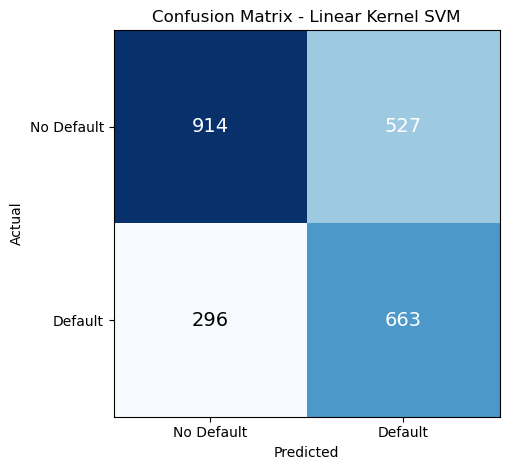

In [49]:
cm_svm_linear = confusion_matrix(y_test, test_pred_svm_linear)

fig, ax = plt.subplots()
im = ax.imshow(cm_svm_linear, cmap='Blues')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['No Default', 'Default'])
ax.set_yticklabels(['No Default', 'Default'])

# Annotating each cell manually so TN/FP/FN/TP all reliably show up
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm_svm_linear[i, j], ha='center', va='center', fontsize=14,
                color='white' if cm_svm_linear[i, j] > cm_svm_linear.max() / 2 else 'black')

ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix - Linear Kernel SVM')
plt.tight_layout()
plt.show()

**Balancing the class weights pays off, recall jumps from ≈0.46 to ≈0.69 on test, with only a small drop in overall accuracy (0.667 to 0.657). The linear kernel still gives the best test AUC (≈0.71) of all four kernels, reinforcing that a straight boundary is a good fit for this data, we've just moved *where* on that boundary's trade-off curve we're operating.**

## <font color="brown"> Model 2: Polynomial Kernel SVM

Now let's allow curved, polynomial boundaries (degree 3 by default).

In [53]:
svm_poly = SVC(kernel='poly', probability=True, class_weight='balanced', random_state=1, degree=3)
svm_poly.fit(X_train_scaled, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'poly'
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",True
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",1
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200


Predicting on the train and test set using the model created.

In [55]:
train_pred_svm_poly = svm_poly.predict(X_train_scaled)
test_pred_svm_poly = svm_poly.predict(X_test_scaled)

train_proba_svm_poly = svm_poly.predict_proba(X_train_scaled)[:, 1]
test_proba_svm_poly = svm_poly.predict_proba(X_test_scaled)[:, 1]

### <font color="blue"> Model 2 Metrics

In [57]:
train_acc_svm_poly = accuracy_score(y_train, train_pred_svm_poly)
test_acc_svm_poly = accuracy_score(y_test, test_pred_svm_poly)

train_recall_svm_poly = recall_score(y_train, train_pred_svm_poly)
test_recall_svm_poly = recall_score(y_test, test_pred_svm_poly)

train_f1_svm_poly = f1_score(y_train, train_pred_svm_poly)
test_f1_svm_poly = f1_score(y_test, test_pred_svm_poly)

train_auc_svm_poly = roc_auc_score(y_train, train_proba_svm_poly)
test_auc_svm_poly = roc_auc_score(y_test, test_proba_svm_poly)

print("Train Accuracy:", train_acc_svm_poly, " Test Accuracy:", test_acc_svm_poly)
print("Train Recall:", train_recall_svm_poly, " Test Recall:", test_recall_svm_poly)
print("Train F1:", train_f1_svm_poly, " Test F1:", test_f1_svm_poly)
print("Train AUC:", train_auc_svm_poly, " Test AUC:", test_auc_svm_poly)

Train Accuracy: 0.8517857142857143  Test Accuracy: 0.6504166666666666
Train Recall: 0.8631484794275492  Test Recall: 0.62148070907195
Train F1: 0.8230277185501066  Test F1: 0.5869030034465781
Train AUC: 0.9379619840933893  Test AUC: 0.6795998897185724


Checking the confusion matrix on the test set.

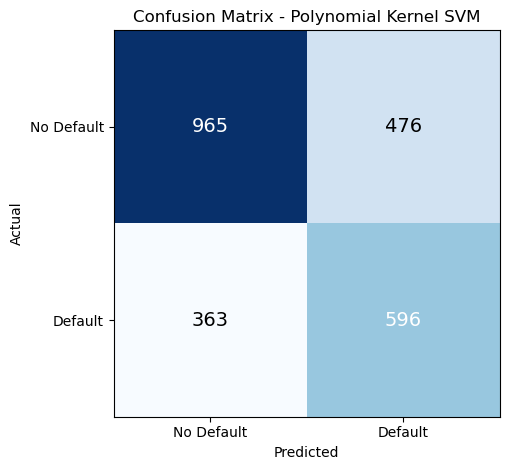

In [59]:
cm_svm_poly = confusion_matrix(y_test, test_pred_svm_poly)

fig, ax = plt.subplots()
im = ax.imshow(cm_svm_poly, cmap='Blues')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['No Default', 'Default'])
ax.set_yticklabels(['No Default', 'Default'])

# Annotating each cell manually so TN/FP/FN/TP all reliably show up
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm_svm_poly[i, j], ha='center', va='center', fontsize=14,
                color='white' if cm_svm_poly[i, j] > cm_svm_poly.max() / 2 else 'black')

ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix - Polynomial Kernel SVM')
plt.tight_layout()
plt.show()

**Balancing the class weights lifts polynomial's recall too (0.31 to 0.62), but it still shows the same overfitting pattern as before, a big gap between train AUC (≈0.94) and test AUC (≈0.68). Balancing the classes changes *where* the boundary sits, it doesn't fix the fact that the boundary itself is chasing curves the data doesn't really have.**

## <font color="brown"> Model 3: RBF Kernel SVM

Now the RBF kernel, which draws smooth, distance-based boundaries and is scikit-learn's default.

In [63]:
svm_rbf = SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=1)
svm_rbf.fit(X_train_scaled, y_train)

,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",True
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",1
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200


Predicting on the train and test set using the model created.

In [65]:
train_pred_svm_rbf = svm_rbf.predict(X_train_scaled)
test_pred_svm_rbf = svm_rbf.predict(X_test_scaled)

train_proba_svm_rbf = svm_rbf.predict_proba(X_train_scaled)[:, 1]
test_proba_svm_rbf = svm_rbf.predict_proba(X_test_scaled)[:, 1]

### <font color="blue"> Model 3 Metrics

In [67]:
train_acc_svm_rbf = accuracy_score(y_train, train_pred_svm_rbf)
test_acc_svm_rbf = accuracy_score(y_test, test_pred_svm_rbf)

train_recall_svm_rbf = recall_score(y_train, train_pred_svm_rbf)
test_recall_svm_rbf = recall_score(y_test, test_pred_svm_rbf)

train_f1_svm_rbf = f1_score(y_train, train_pred_svm_rbf)
test_f1_svm_rbf = f1_score(y_test, test_pred_svm_rbf)

train_auc_svm_rbf = roc_auc_score(y_train, train_proba_svm_rbf)
test_auc_svm_rbf = roc_auc_score(y_test, test_proba_svm_rbf)

print("Train Accuracy:", train_acc_svm_rbf, " Test Accuracy:", test_acc_svm_rbf)
print("Train Recall:", train_recall_svm_rbf, " Test Recall:", test_recall_svm_rbf)
print("Train F1:", train_f1_svm_rbf, " Test F1:", test_f1_svm_rbf)
print("Train AUC:", train_auc_svm_rbf, " Test AUC:", test_auc_svm_rbf)

Train Accuracy: 0.7814285714285715  Test Accuracy: 0.65875
Train Recall: 0.8023255813953488  Test Recall: 0.6402502606882169
Train F1: 0.7456359102244389  Test F1: 0.5999022960429897
Train AUC: 0.8626575133104597  Test AUC: 0.7000804678132365


Checking the confusion matrix on the test set.

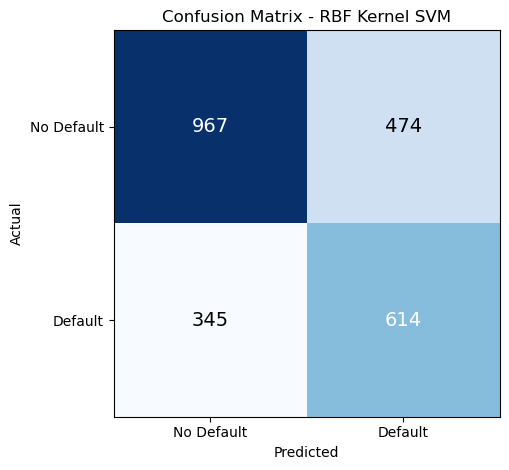

In [69]:
cm_svm_rbf = confusion_matrix(y_test, test_pred_svm_rbf)

fig, ax = plt.subplots()
im = ax.imshow(cm_svm_rbf, cmap='Blues')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['No Default', 'Default'])
ax.set_yticklabels(['No Default', 'Default'])

# Annotating each cell manually so TN/FP/FN/TP all reliably show up
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm_svm_rbf[i, j], ha='center', va='center', fontsize=14,
                color='white' if cm_svm_rbf[i, j] > cm_svm_rbf.max() / 2 else 'black')

ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix - RBF Kernel SVM')
plt.tight_layout()
plt.show()

**RBF's recall improves to ≈0.64, and it continues to sit between polynomial and linear on AUC (≈0.70), a reasonable, well-balanced kernel here, just not quite as strong as linear.**

## <font color="brown"> Model 4: Sigmoid Kernel SVM

Finally, the sigmoid kernel, included mainly for completeness and comparison.

In [73]:
svm_sigmoid = SVC(kernel='sigmoid', probability=True, class_weight='balanced', random_state=1)
svm_sigmoid.fit(X_train_scaled, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'sigmoid'
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",True
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",1
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200


Predicting on the train and test set using the model created.

In [75]:
train_pred_svm_sigmoid = svm_sigmoid.predict(X_train_scaled)
test_pred_svm_sigmoid = svm_sigmoid.predict(X_test_scaled)

train_proba_svm_sigmoid = svm_sigmoid.predict_proba(X_train_scaled)[:, 1]
test_proba_svm_sigmoid = svm_sigmoid.predict_proba(X_test_scaled)[:, 1]

### <font color="blue"> Model 4 Metrics

In [77]:
train_acc_svm_sigmoid = accuracy_score(y_train, train_pred_svm_sigmoid)
test_acc_svm_sigmoid = accuracy_score(y_test, test_pred_svm_sigmoid)

train_recall_svm_sigmoid = recall_score(y_train, train_pred_svm_sigmoid)
test_recall_svm_sigmoid = recall_score(y_test, test_pred_svm_sigmoid)

train_f1_svm_sigmoid = f1_score(y_train, train_pred_svm_sigmoid)
test_f1_svm_sigmoid = f1_score(y_test, test_pred_svm_sigmoid)

train_auc_svm_sigmoid = roc_auc_score(y_train, train_proba_svm_sigmoid)
test_auc_svm_sigmoid = roc_auc_score(y_test, test_proba_svm_sigmoid)

print("Train Accuracy:", train_acc_svm_sigmoid, " Test Accuracy:", test_acc_svm_sigmoid)
print("Train Recall:", train_recall_svm_sigmoid, " Test Recall:", test_recall_svm_sigmoid)
print("Train F1:", train_f1_svm_sigmoid, " Test F1:", test_f1_svm_sigmoid)
print("Train AUC:", train_auc_svm_sigmoid, " Test AUC:", test_auc_svm_sigmoid)

Train Accuracy: 0.5603571428571429  Test Accuracy: 0.6320833333333333
Train Recall: 0.5483005366726297  Test Recall: 0.6506777893639207
Train F1: 0.49898249898249897  Test F1: 0.5856405443453777
Train AUC: 0.5893827546855157  Test AUC: 0.6807280310929945


Checking the confusion matrix on the test set.

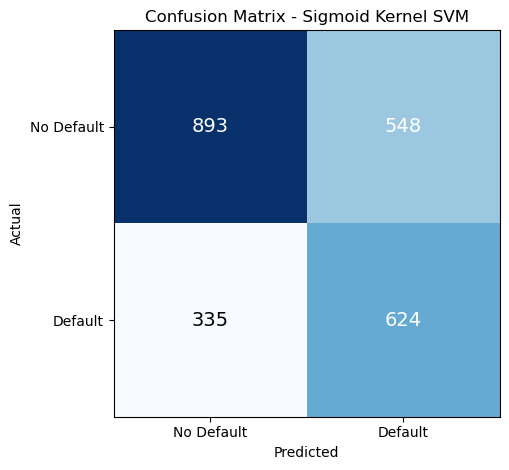

In [79]:
cm_svm_sigmoid = confusion_matrix(y_test, test_pred_svm_sigmoid)

fig, ax = plt.subplots()
im = ax.imshow(cm_svm_sigmoid, cmap='Blues')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['No Default', 'Default'])
ax.set_yticklabels(['No Default', 'Default'])

# Annotating each cell manually so TN/FP/FN/TP all reliably show up
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm_svm_sigmoid[i, j], ha='center', va='center', fontsize=14,
                color='white' if cm_svm_sigmoid[i, j] > cm_svm_sigmoid.max() / 2 else 'black')

ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix - Sigmoid Kernel SVM')
plt.tight_layout()
plt.show()

**Sigmoid's recall also improves substantially (0.47 to 0.65), similar to RBF, but its AUC (≈0.68) remains the weakest of the four, consistent with the messier boundary we saw in the toy-data diagram earlier.**

## <font color="brown"> Model Performance Comparison

In [82]:
comparison_df = pd.DataFrame({
    'Kernel': ['Linear', 'Polynomial', 'RBF', 'Sigmoid'],
    'Train Accuracy': [train_acc_svm_linear, train_acc_svm_poly, train_acc_svm_rbf, train_acc_svm_sigmoid],
    'Test Accuracy': [test_acc_svm_linear, test_acc_svm_poly, test_acc_svm_rbf, test_acc_svm_sigmoid],
    'Train Recall': [train_recall_svm_linear, train_recall_svm_poly, train_recall_svm_rbf, train_recall_svm_sigmoid],
    'Test Recall': [test_recall_svm_linear, test_recall_svm_poly, test_recall_svm_rbf, test_recall_svm_sigmoid],
    'Train F1': [train_f1_svm_linear, train_f1_svm_poly, train_f1_svm_rbf, train_f1_svm_sigmoid],
    'Test F1': [test_f1_svm_linear, test_f1_svm_poly, test_f1_svm_rbf, test_f1_svm_sigmoid],
    'Train AUC': [train_auc_svm_linear, train_auc_svm_poly, train_auc_svm_rbf, train_auc_svm_sigmoid],
    'Test AUC': [test_auc_svm_linear, test_auc_svm_poly, test_auc_svm_rbf, test_auc_svm_sigmoid],
})
comparison_df

,Kernel,Train Accuracy,Test Accuracy,Train Recall,Test Recall,Train F1,Test F1,Train AUC,Test AUC
0,Linear,0.650536,0.657083,0.681127,0.691345,0.608835,0.617031,0.718178,0.712087
1,Polynomial,0.851786,0.650417,0.863148,0.621481,0.823028,0.586903,0.937962,0.679600
2,RBF,0.781429,0.658750,0.802326,0.640250,0.745636,0.599902,0.862658,0.700080
3,Sigmoid,0.560357,0.632083,0.548301,0.650678,0.498982,0.585641,0.589383,0.680728


Balancing the class weights was a clear win across every kernel, recall roughly doubled for polynomial and improved substantially for all four, at only a modest cost to accuracy. The **linear kernel** still comes out on top overall, best test AUC and best recall of the four, confirming again that this credit dataset doesn't have the kind of complex, curved structure that would make the extra flexibility of polynomial or RBF kernels pay off.

## <font color="brown"> Conclusion

* **Linear kernel** gave the best overall performance here, both AUC and recall. When a straight boundary already separates the classes reasonably well, the added flexibility of a non-linear kernel doesn't help.
* **Polynomial kernel** underperformed the others and overfit the most (train AUC ≈0.94 vs test AUC ≈0.68), bending the boundary into curves that the true relationship in this data didn't actually call for.
* **RBF and Sigmoid kernels** landed in between, reasonable but not better than the simple linear boundary.
* **`class_weight='balanced'` made a real difference across every kernel**: recall roughly doubled for the polynomial kernel and improved substantially for all four, at only a modest cost to accuracy. SVM's default boundary doesn't know that missing a defaulter is usually costlier than a false alarm, `class_weight` is how we tell it that.
* This is a useful general lesson for choosing an SVM kernel: **start with linear** as a fast, interpretable baseline, and only reach for RBF or polynomial if there's a real, visible non-linear pattern in the data (the way there clearly was in our toy "concentric circles" example) that a straight line genuinely cannot capture. And regardless of kernel, **check whether `class_weight='balanced'` (or manual threshold tuning) is needed** whenever recall on the minority class matters.
* For deployment here, the **linear kernel SVM with balanced class weights** is both the strongest performer and the fastest and easiest to explain, a rare win on all fronts.